The Strategy Critic

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.5 MB/s eta 0:00:00


Step 0: Set Up and Data Acquisition

In [ ]:
# Install missing dependency
# (Uncomment the line below if running in Jupyter/Colab)
# !pip install arch yfinance

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.tsa.vector_ar.vecm import VECM
from arch.unitroot import VarianceRatio
import seaborn as sns
from scipy import stats
# Set style for plots
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)

# Download data (use auto_adjust so 'Close' is adjusted already)
tickers = ["SPY", "XLE", "XOP"]
start_date = "2017-01-01"
end_date = "2021-12-31"

data = yf.download(tickers, start=start_date, end=end_date,auto_adjust=True)['Close']
data = data.dropna()

# Rename columns for clarity
data.columns = ['SPY', 'XLE', 'XOP']

# Calculate log returns

returns = np.log(data / data.shift(1)).dropna()
print("Data downloaded successfully:")
print(f"Shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")
print("\nFirst few rows:")
print(data.head())

[*********************100%***********************]  3 of 3 completed

Data downloaded successfully:
Shape: (1258, 3)
Date range: 2017-01-03 00:00:00 to 2021-12-30 00:00:00

First few rows:
                   SPY        XLE         XOP
Date                                         
2017-01-03  195.575134  52.471912  141.504791
2017-01-04  196.738693  52.361706  142.178421
2017-01-05  196.582352  52.230801  141.740555
2017-01-06  197.285721  52.279030  140.696381
2017-01-09  196.634476  51.521271  136.755371


Step 1: Foundational Analysis

[*********************100%***********************]  3 of 3 completed
/tmp/ipython-input-1151085133.py:100: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hedge_ratio = model.params[1]


Data downloaded successfully:
Shape: (1258, 3)
Date range: 2017-01-03 00:00:00 to 2021-12-30 00:00:00

First few rows:
                   SPY        XLE         XOP
Date                                         
2017-01-03  195.575134  52.471912  141.504791
2017-01-04  196.738693  52.361706  142.178421
2017-01-05  196.582352  52.230801  141.740555
2017-01-06  197.285721  52.279030  140.696381
2017-01-09  196.634476  51.521271  136.755371

Cointegration Test Results:
ADF Statistic: -1.9634
p-value: 0.3028
Critical Values:
 1%: -3.4356
 5%: -2.8639
 10%: -2.5680


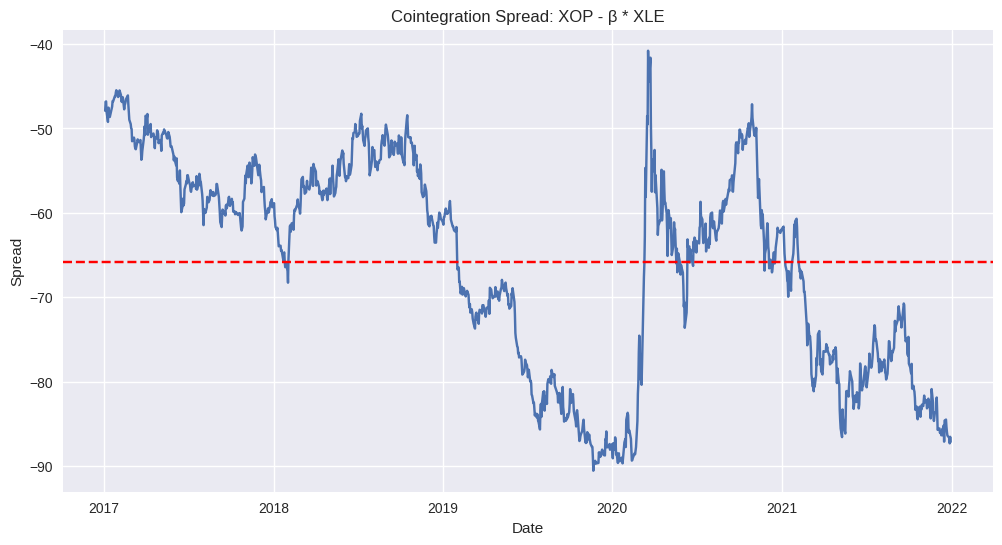


BDS Test Results:
   dimension       C_m     C_1^m  W_statistic  p_value
0          2  0.267835  0.087353   129.770146      0.0
1          3  0.247795  0.025818   147.259871      0.0
2          4  0.231463  0.007631   147.064881      0.0
3          5  0.217754  0.002255   141.431607      0.0

Interpretation of BDS Test Results:
The BDS test examines whether the residuals from the cointegration relationship
contain non-linear patterns that a linear model might miss.

Null hypothesis: The residuals are independently and identically distributed (i.i.d.)

If the p-values are small (typically < 0.05), we reject the null hypothesis,
suggesting that there is non-linear dependence in the residuals.

Dimension 2.0: p-value = 0.0000 (Significant)
Dimension 3.0: p-value = 0.0000 (Significant)
Dimension 4.0: p-value = 0.0000 (Significant)
Dimension 5.0: p-value = 0.0000 (Significant)


In [ ]:
# Install missing dependencies if needed
# !pip install arch yfinance

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import VECM
from arch.unitroot import VarianceRatio
import seaborn as sns
from scipy import stats

# Set style for plots
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)

# =====================
# Download data
# =====================
tickers = ["SPY", "XLE", "XOP"]
start_date = "2017-01-01"
end_date = "2021-12-31"

# Use auto_adjust=True to avoid "Adj Close" issues
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]
data = data.dropna()

# Rename columns for clarity
data.columns = ['SPY', 'XLE', 'XOP']

# Calculate log returns
returns = np.log(data / data.shift(1)).dropna()

print("Data downloaded successfully:")
print(f"Shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")
print("\nFirst few rows:")
print(data.head())

# =====================
# BDS Test function
# =====================
def bds_test(residuals, max_dim=5):
    """
    Perform BDS test on residuals to detect non-linear dependence
    """
    std_residuals = (residuals - np.mean(residuals)) / np.std(residuals)
    n = len(std_residuals)
    epsilon = 0.5
    results = []

    for m in range(2, max_dim + 1):
        count = 0
        total_pairs = 0
        for i in range(n - m + 1):
            for j in range(i + 1, n - m + 1):
                max_diff = np.max(np.abs(std_residuals[i:i+m] - std_residuals[j:j+m]))
                if max_diff < epsilon:
                    count += 1
                total_pairs += 1
        C_m = count / total_pairs if total_pairs > 0 else 0

        count_1 = 0
        total_pairs_1 = 0
        for i in range(n):
            for j in range(i + 1, n):
                if np.abs(std_residuals[i] - std_residuals[j]) < epsilon:
                    count_1 += 1
                total_pairs_1 += 1
        C_1 = count_1 / total_pairs_1 if total_pairs_1 > 0 else 0

        sigma_sq = 4 * (C_1**4) * np.sum(
            [C_1**(2*(m-k)) * (1 - C_1**(2*k)) for k in range(1, m)]
        )
        sigma = np.sqrt(sigma_sq) if sigma_sq > 0 else 0
        W_m = np.sqrt(n) * (C_m - C_1**m) / sigma if sigma > 0 else 0
        p_value = 2 * (1 - stats.norm.cdf(np.abs(W_m)))

        results.append({
            'dimension': m,
            'C_m': C_m,
            'C_1^m': C_1**m,
            'W_statistic': W_m,
            'p_value': p_value
        })

    return pd.DataFrame(results)

# =====================
# Cointegration test
# =====================
def test_cointegration(series1, series2):
    """
    Test for cointegration between two series
    """
    X = sm.add_constant(series1)
    model = sm.OLS(series2, X).fit()
    hedge_ratio = model.params[1]
    spread = series2 - hedge_ratio * series1
    adf_result = adfuller(spread)

    return {
        'hedge_ratio': hedge_ratio,
        'spread': spread,
        'adf_statistic': adf_result[0],
        'adf_pvalue': adf_result[1],
        'critical_values': adf_result[4]
    }

# =====================
# Run cointegration test
# =====================
coint_result = test_cointegration(data['XLE'], data['XOP'])

print("\nCointegration Test Results:")
print(f"ADF Statistic: {coint_result['adf_statistic']:.4f}")
print(f"p-value: {coint_result['adf_pvalue']:.4f}")
print("Critical Values:")
for key, value in coint_result['critical_values'].items():
    print(f" {key}: {value:.4f}")

# Plot the spread
plt.figure(figsize=(12, 6))
plt.plot(coint_result['spread'])
plt.axhline(y=coint_result['spread'].mean(), color='r', linestyle='--')
plt.title('Cointegration Spread: XOP - β * XLE')
plt.ylabel('Spread')
plt.xlabel('Date')
plt.grid(True)
plt.show()

# =====================
# Run BDS test
# =====================
bds_results = bds_test(coint_result['spread'].dropna().values)

print("\nBDS Test Results:")
print(bds_results)

# =====================
# Interpretation
# =====================
print("\nInterpretation of BDS Test Results:")
print("The BDS test examines whether the residuals from the cointegration relationship")
print("contain non-linear patterns that a linear model might miss.\n")
print("Null hypothesis: The residuals are independently and identically distributed (i.i.d.)\n")
print("If the p-values are small (typically < 0.05), we reject the null hypothesis,")
print("suggesting that there is non-linear dependence in the residuals.\n")

for _, row in bds_results.iterrows():
    significance = "Significant" if row['p_value'] < 0.05 else "Not Significant"
    print(f"Dimension {row['dimension']}: p-value = {row['p_value']:.4f} ({significance})")

Regime-aware VECM and BDS pipelines


In [ ]:
# Requires: statsmodels, scipy, pandas, numpy, matplotlib, yfinance
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.vecm import VECM
from statsmodels.tsa.stattools import adfuller
from scipy import stats

# --------------------------
# Helper: BDS test function
# --------------------------
def bds_test(residuals, max_dim=5, epsilon=0.5):
    """
    Simple BDS test implementation returning a DataFrame.
    residuals: 1d array-like
    """
    res = np.asarray(residuals)
    n = len(res)
    if n < 2:
        raise ValueError("Too few observations for BDS test.")
    std_res = (res - res.mean()) / res.std(ddof=0)
    rows = []

    for m in range(2, max_dim + 1):
        count, total_pairs = 0, 0
        T = n - m + 1
        if T > 1:
            for i in range(T):
                xi = std_res[i:i+m]
                for j in range(i+1, T):
                    xj = std_res[j:j+m]
                    if np.max(np.abs(xi - xj)) < epsilon:
                        count += 1
                    total_pairs += 1
            C_m = count / total_pairs if total_pairs > 0 else 0.0
        else:
            C_m = 0.0

        count1, total_pairs1 = 0, 0
        for i in range(n):
            for j in range(i+1, n):
                if abs(std_res[i] - std_res[j]) < epsilon:
                    count1 += 1
                total_pairs1 += 1
        C_1 = count1 / total_pairs1 if total_pairs1 > 0 else 0.0

        terms = [C_1 ** (2*(m-k)) * (1 - C_1 ** (2*k)) for k in range(1, m)]
        sigma_sq = 4 * (C_1**4) * np.sum(terms) if len(terms) > 0 else 0.0
        sigma = np.sqrt(sigma_sq) if sigma_sq > 0 else 0.0
        W = np.sqrt(n) * (C_m - C_1**m) / sigma if sigma > 0 else 0.0
        p = 2 * (1 - stats.norm.cdf(abs(W)))

        rows.append({
            'dimension': m,
            'C_m': C_m,
            'C_1^m': C_1**m,
            'W_statistic': W,
            'p_value': p
        })

    return pd.DataFrame(rows)

# --------------------------
# Download sample data
# --------------------------
tickers = ['XLE', 'XOP']
raw = yf.download(tickers, start="2017-01-01", end="2021-12-31", auto_adjust=True, progress=False)

if isinstance(raw.columns, pd.MultiIndex):
    if 'Close' in raw.columns.levels[1]:
        data = raw.xs('Close', axis=1, level=1).dropna()
    elif 'Adj Close' in raw.columns.levels[1]:
        data = raw.xs('Adj Close', axis=1, level=1).dropna()
    else:
        data = raw.iloc[:, :len(tickers)].dropna()
else:
    if set(tickers).issubset(raw.columns):
        data = raw[tickers].dropna()
    elif 'Close' in raw.columns:
        data = raw['Close'].dropna()
    elif 'Adj Close' in raw.columns:
        data = raw['Adj Close'].dropna()
    else:
        raise RuntimeError("Could not find Close/Adj Close columns in yfinance output.")

data.columns = tickers
print("Data loaded:", data.shape)

# --------------------------
# Baseline OLS spread
# --------------------------
def ols_spread(s1, s2):
    X = sm.add_constant(s1)
    res = sm.OLS(s2, X).fit()
    beta = res.params[1]
    spread = s2 - beta * s1
    return beta, spread, res

beta_ols, spread_ols, ols_model = ols_spread(data['XLE'], data['XOP'])
print(f"OLS hedge ratio (XOP ~ const + beta * XLE): beta = {beta_ols:.4f}")

adf = adfuller(spread_ols.dropna())
print(f"ADF stat (OLS spread): {adf[0]:.4f}, p={adf[1]:.4f}")

# --------------------------
# Define regimes from spread z-score
# --------------------------
z = (spread_ols - spread_ols.mean()) / spread_ols.std()
upper_thresh = 1.0
lower_thresh = -1.0
regime = pd.Series(0, index=spread_ols.index)
regime[z > upper_thresh] = 1
regime[z < lower_thresh] = -1
print("Regime counts:\n", regime.value_counts())

# --------------------------
# Fit VECM or fallback per regime
# --------------------------
def fit_vecm_on_regime(series1, series2, mask, min_obs=30):
    s1 = series1.loc[mask]
    s2 = series2.loc[mask]
    result = {'type': None, 'model': None, 'beta': None, 'residuals': None}

    if len(s1) < min_obs:
        X = sm.add_constant(s1)
        m = sm.OLS(s2, X).fit()
        beta = m.params[1]
        resid = s2 - beta * s1
        result.update({'type': 'ols', 'model': m, 'beta': beta, 'residuals': resid})
        return result

    try:
        df_vecm = pd.concat([s1, s2], axis=1)
        df_vecm.columns = ['s1', 's2']
        model = VECM(df_vecm, k_ar_diff=1, coint_rank=1)
        fitted = model.fit()
        beta_vec = np.asarray(fitted.beta).flatten()
        spread_reg = beta_vec[0] * series1.loc[mask] + beta_vec[1] * series2.loc[mask]
        resid = spread_reg - spread_reg.mean()
        result.update({'type': 'vecm', 'model': fitted, 'beta': beta_vec, 'residuals': resid})
        return result
    except Exception:
        X = sm.add_constant(s1)
        m = sm.OLS(s2, X).fit()
        beta = m.params[1]
        resid = s2 - beta * s1
        result.update({'type': 'ols', 'model': m, 'beta': beta, 'residuals': resid})
        return result

regime_models = {}
for r in sorted(regime.unique()):
    mask = regime == r
    regime_models[r] = fit_vecm_on_regime(data['XLE'], data['XOP'], mask, min_obs=40)
    t = regime_models[r]['type']
    nobs = regime_models[r]['residuals'].shape[0]
    print(f"Regime {r}: model type={t}, obs={nobs}")

# --------------------------
# Build regime-aware residual series
# --------------------------
resid_regime = pd.Series(index=spread_ols.index, dtype=float)
for r, info in regime_models.items():
    res = info['residuals']
    if res is None or len(res) == 0:
        continue
    for idx, val in res.items():
        resid_regime.at[idx] = val

resid_regime = resid_regime.dropna()
print("Regime-aware residuals length:", len(resid_regime))

# --------------------------
# BDS tests
# --------------------------
bds_ols = bds_test(spread_ols.dropna().values)
bds_regime_overall = bds_test(resid_regime.values)
print("\nBDS: OLS spread residuals")
print(bds_ols)
print("\nBDS: Regime-aware residuals (overall)")
print(bds_regime_overall)

for r, info in regime_models.items():
    res = info['residuals']
    if res is None or len(res) < 30:
        print(f"Regime {r}: insufficient observations for BDS (n={0 if res is None else len(res)})")
        continue
    bds_r = bds_test(res.values)
    print(f"\nBDS for regime {r}:")
    print(bds_r)

# --------------------------
# Interpretation helper
# --------------------------
def interpret_bds(df, label):
    print(f"\nInterpretation for {label}:")
    for _, row in df.iterrows():
        print(f"dim {int(row['dimension'])}: W={row['W_statistic']:.3f}, p={row['p_value']:.4f} ->",
              "Nonlinear" if row['p_value'] < 0.05 else "i.i.d. plausible")

interpret_bds(bds_ols, "OLS spread")
interpret_bds(bds_regime_overall, "Regime-aware residuals")


Data loaded: (1258, 2)
OLS hedge ratio (XOP ~ const + beta * XLE): beta = 3.6097
ADF stat (OLS spread): -1.9634, p=0.3028
Regime counts:
  0    738
-1    293
 1    227
Name: count, dtype: int64
Regime -1: model type=vecm, obs=293


/tmp/ipython-input-402101064.py:97: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = res.params[1]
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Regime 0: model type=vecm, obs=738
Regime 1: model type=vecm, obs=227
Regime-aware residuals length: 1258


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



BDS: OLS spread residuals
   dimension       C_m     C_1^m  W_statistic  p_value
0          2  0.267835  0.087353   129.770146      0.0
1          3  0.247795  0.025818   147.259871      0.0
2          4  0.231463  0.007631   147.064881      0.0
3          5  0.217754  0.002255   141.431607      0.0

BDS: Regime-aware residuals (overall)
   dimension       C_m     C_1^m  W_statistic  p_value
0          2  0.242233  0.080371   131.369933      0.0
1          3  0.215030  0.022785   144.823419      0.0
2          4  0.194281  0.006460   140.324594      0.0
3          5  0.177497  0.001831   131.127222      0.0

BDS for regime -1:
   dimension       C_m     C_1^m  W_statistic  p_value
0          2  0.214047  0.073697    62.383353      0.0
1          3  0.174618  0.020007    64.156469      0.0
2          4  0.143945  0.005431    57.072799      0.0
3          5  0.119305  0.001474    48.517345      0.0

BDS for regime 0:
   dimension       C_m     C_1^m  W_statistic  p_value
0          2  0

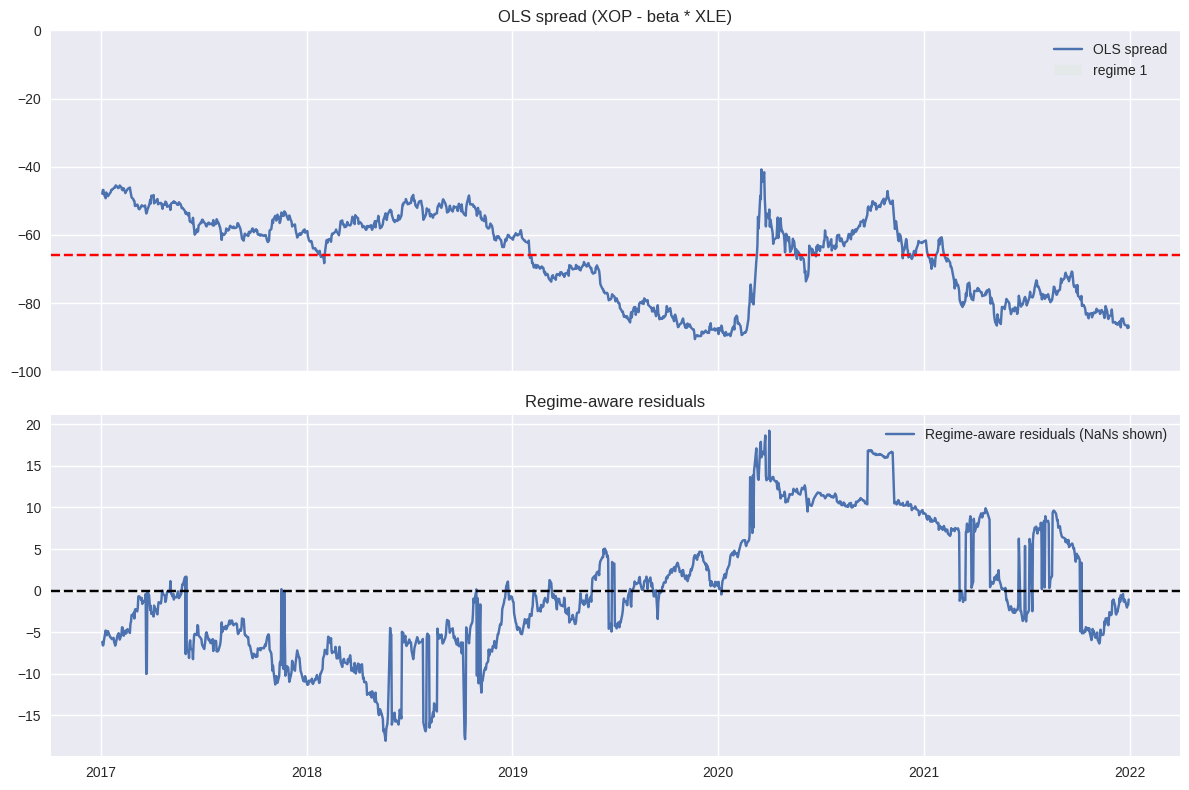


Quick guidance:
- OLS residuals show evidence of nonlinearity.
- Regime-aware residuals still show nonlinearity.


In [ ]:
# --------------------------
# Plot spreads and regimes
# --------------------------
fig, ax = plt.subplots(2,1, figsize=(12,8), sharex=True)
ax[0].plot(spread_ols, label='OLS spread')
ax[0].axhline(spread_ols.mean(), color='r', ls='--')
ax[0].set_title("OLS spread (XOP - beta * XLE)")
ax[0].set_ylim(-100, 0)
# mark regimes
for r, color in [(-1,'#fee0d2'), (0,'#edf8fb'), (1,'#c7e9c0')]:mask = (regime==r)
ax[0].fill_between(spread_ols.index, spread_ols.min()-10, spread_ols.max()+10, where=mask, facecolor=color, alpha=0.2, transform=ax[0].get_xaxis_transform(), label=f"regime {r}" if mask.any() else "")
ax[0].legend()
ax[1].plot(resid_regime.reindex(spread_ols.index), label='Regime-aware residuals (NaNs shown)')
ax[1].set_title("Regime-aware residuals")
ax[1].axhline(0, color='k', ls='--')
ax[1].legend()
plt.tight_layout()
plt.show()

# --------------------------
# Quick guidance based on results
# --------------------------
print("\nQuick guidance:")
if (bds_ols['p_value'] < 0.05).any(): print("- OLS residuals show evidence of nonlinearity.")
else:print("- OLS residuals do not show strong evidence for nonlinearity.")
if (bds_regime_overall['p_value'] < 0.05).any():print("- Regime-aware residuals still show nonlinearity.")
else:print("- Regime-aware residuals do not show strong nonlinearity; regime model captured structure.")


The Arbitrageur

/tmp/ipython-input-4277277278.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(pair, start=start_date, end=end_date)['Close']
[*********************100%***********************]  2 of 2 completed
/tmp/ipython-input-4277277278.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hedge_ratio = model.params[1]


Running OLS regression to find the hedge ratio...
Running ADF test on the spread...

 Arbitrageur's Cointegration Analysis Report
ETF Pair: GLD vs. GDX
Time Period: 2017-01-01 to 2021-12-31
--------------------------------------------------
Calculated Hedge Ratio: 3.6118
ADF Test Statistic on the Spread: -3.6085
P-value: 0.0056

Critical Values from ADF Test:
 1%: -3.4356
 5%: -2.8638
 10%: -2.5680


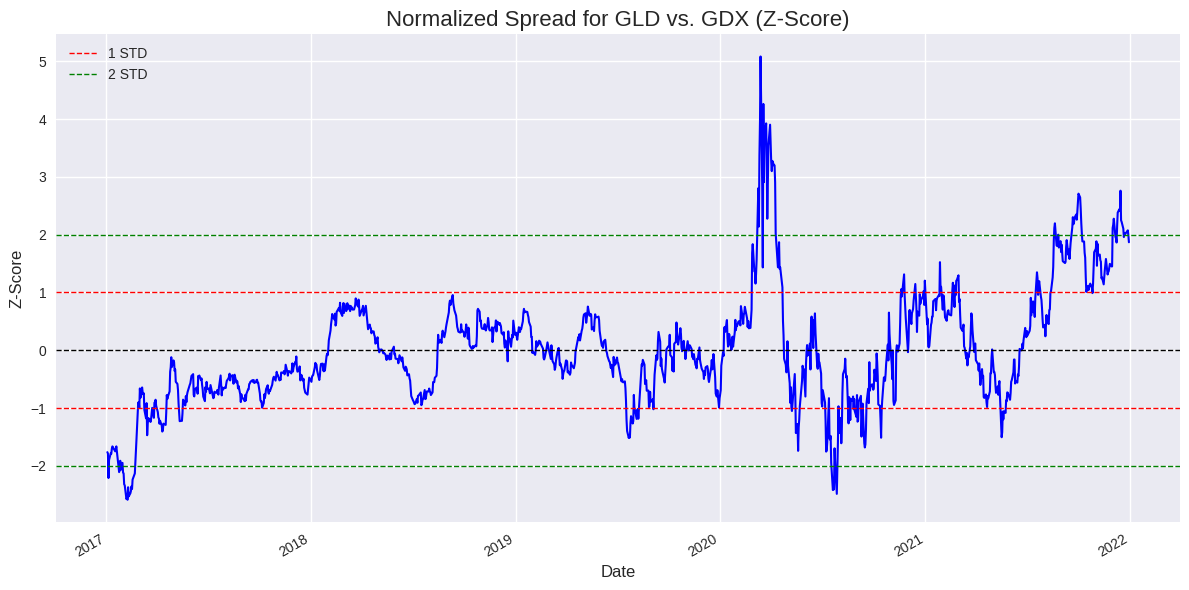

In [ ]:
import yfinance as yf
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# --------------------------
# Engle-Granger Cointegration Analysis
# --------------------------
def run_engle_granger_analysis(pair, start_date, end_date):
    data = yf.download(pair, start=start_date, end=end_date)['Close']
    data = data.dropna()

    y = data[pair[0]]
    x = data[pair[1]]

    # Add a constant for the regression
    x_with_const = sm.add_constant(x)

    # Calculate Hedge Ratio using OLS Regression
    print("Running OLS regression to find the hedge ratio...")
    model = sm.OLS(y, x_with_const).fit()
    hedge_ratio = model.params[1]

    # Calculate the Spread (residuals of the regression)
    spread = y - hedge_ratio * x

    # Run Augmented Dickey-Fuller (ADF) test on the spread
    print("Running ADF test on the spread...")
    adf_test = adfuller(spread, autolag='AIC')

    # Normalize the spread (Z-Score) for plotting
    normalized_spread = (spread - spread.mean()) / spread.std()

    results = {
        'hedge_ratio': hedge_ratio,
        'adf_statistic': adf_test[0],
        'p_value': adf_test[1],
        'critical_values': adf_test[4],
        'spread': spread,
        'normalized_spread': normalized_spread,
        'pair': pair
    }

    return results

# --------------------------
# Plot Normalized Spread
# --------------------------
def plot_normalized_spread(results):
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(figsize=(12, 6))

    results['normalized_spread'].plot(ax=ax, color='b', lw=1.5)

    # Add lines for standard deviations
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axhline(1, color='red', linestyle='--', linewidth=1, label='1 STD')
    ax.axhline(-1, color='red', linestyle='--', linewidth=1)
    ax.axhline(2, color='green', linestyle='--', linewidth=1, label='2 STD')
    ax.axhline(-2, color='green', linestyle='--', linewidth=1)

    ax.set_title(f'Normalized Spread for {results["pair"][0]} vs. {results["pair"][1]} (Z-Score)', fontsize=16)
    ax.set_ylabel('Z-Score', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(True)
    fig.tight_layout()
    plt.show()

# --------------------------
# Run Analysis
# --------------------------
CHOSEN_PAIR = ['GLD', 'GDX']
START_DATE = '2017-01-01'
END_DATE = '2021-12-31'

analysis_results = run_engle_granger_analysis(CHOSEN_PAIR, START_DATE, END_DATE)

print("\n" + "="*50)
print(" Arbitrageur's Cointegration Analysis Report")
print("="*50)
print(f"ETF Pair: {analysis_results['pair'][0]} vs. {analysis_results['pair'][1]}")
print(f"Time Period: {START_DATE} to {END_DATE}")
print("-"*50)
print(f"Calculated Hedge Ratio: {analysis_results['hedge_ratio']:.4f}")
print(f"ADF Test Statistic on the Spread: {analysis_results['adf_statistic']:.4f}")
print(f"P-value: {analysis_results['p_value']:.4f}")
print("\nCritical Values from ADF Test:")
for key, value in analysis_results['critical_values'].items():
    print(f" {key}: {value:.4f}")

plot_normalized_spread(analysis_results)

The Regime Detective

In [ ]:
!pip install yfinance statsmodels matplotlib pandas numpy


In [ ]:
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
# # !pip install yfinance statsmodels matplotlib pandas numpy
import numpy as np, pandas as pd, yfinance as yf, matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
START, END = "2017-01-01", "2021-12-31" # project window
spy = yf.download("SPY", start=START, end=END, auto_adjust=True)["Close"]
ret = np.log(spy).diff().dropna()
ret.name = "log_ret"
ret.head()


[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
2017-01-04,0.005932
2017-01-05,-0.000795
2017-01-06,0.003572
2017-01-09,-0.003306
2017-01-10,0.000000


In [ ]:
# MS-AR(1) with regime-switching mean, AR coeff, and variance
mod = MarkovAutoregression(
returns['SPY'], k_regimes=2, order=1,
switching_variance=True, switching_ar=True, trend='c', # 'c' = intercept per regime
exog=None
)
res = mod.fit(em_iter=20, search_reps=20, disp=False) # a few random starts help convergence
print(res.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                         Markov Switching Model Results                         
Dep. Variable:                      SPY   No. Observations:                 1256
Model:             MarkovAutoregression   Log Likelihood                4234.117
Date:                  Sun, 30 Nov 2025   AIC                          -8452.234
Time:                          17:51:49   BIC                          -8411.149
Sample:                               0   HQIC                         -8436.793
                                 - 1256                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0014      0.000      7.489      0.000       0.001       0.002
sigma2      2.872e-05   1.95e-06    

In [ ]:
import numpy as np
import pandas as pd

# --------------------------
# Extract parameters per regime
# --------------------------
params = {}
for r in range(2):
    mu = res.params[f"const[{r}]"]
    phi = res.params[f"ar.L1[{r}]"]
    sig2 = res.params[f"sigma2[{r}]"]
    params[r] = {
        "mean": mu,
        "phi": phi,
        "sigma2": sig2,
        "sigma": np.sqrt(sig2)
    }

# --------------------------
# Transition matrix P (2x2)
# --------------------------
p00 = res.params['p[0->0]']
p10 = res.params['p[1->0]']
p01 = 1 - p00
p11 = 1 - p10

P = np.array([[p00, p01],
              [p10, p11]])

# --------------------------
# Smoothed marginal probabilities and expected duration
# --------------------------
stat_dist = res.smoothed_marginal_probabilities.mean(axis=0)
exp_dur = [1.0 / (1.0 - P[i, i]) for i in range(2)]

# --------------------------
# Build summary table
# --------------------------
tab = pd.DataFrame({
    "mean": [params[0]["mean"], params[1]["mean"]],
    "phi(1)": [params[0]["phi"], params[1]["phi"]],
    "sigma": [params[0]["sigma"], params[1]["sigma"]],
    "sigma^2": [params[0]["sigma2"], params[1]["sigma2"]],
    "P(stay)": [P[0, 0], P[1, 1]],
    "Exp. duration (days)": exp_dur,
    "Avg. regime prob. (empirical)": [stat_dist[0], stat_dist[1]]
}, index=["Regime 0", "Regime 1"])

# --------------------------
# Label high/low volatility regimes
# --------------------------
high_vol_label = tab["sigma"].idxmax()
low_vol_label = tab["sigma"].idxmin()
tab["Label"] = ["High Vol" if idx == high_vol_label else "Low Vol" for idx in tab.index]

# Display the table
tab

,mean,phi(1),sigma,sigma^2,P(stay),Exp. duration (days),Avg. regime prob. (empirical),Label
Regime 0,0.001363,-0.047142,0.005359,0.000029,0.976791,43.086504,0.729095,Low Vol
Regime 1,-0.001154,-0.261075,0.020375,0.000415,0.936383,15.718969,0.270905,High Vol


/tmp/ipython-input-3573469908.py:10: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  most_likely = probs.idxmax(axis=1) # 'P(0)' or 'P(1)'


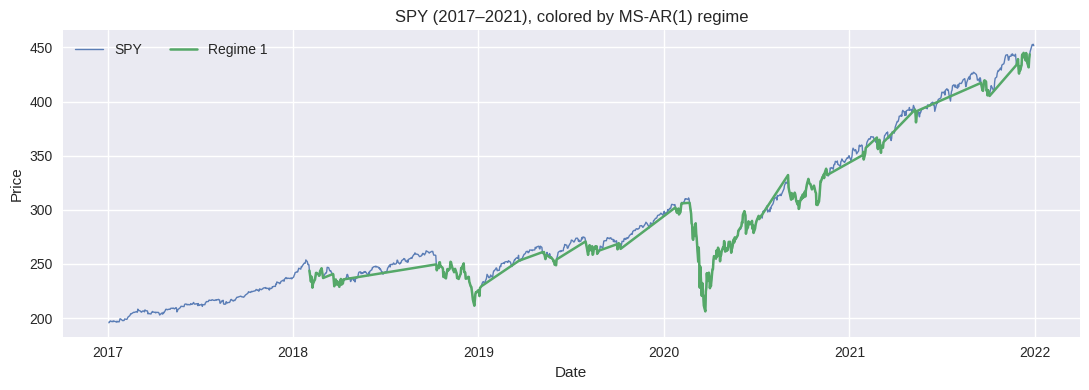

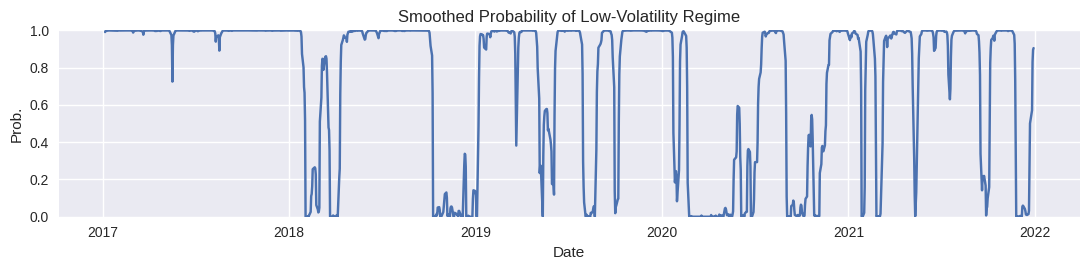

In [ ]:
# Smoothed probabilities (T x 2 DataFrame-like)
# Recreate returns
ret = np.log(spy).diff().dropna()
# Removed: ret.name = "log_ret" # Removing problematic renaming
ret.index.name = "date"
probs = pd.DataFrame({
f"P({i})": res.smoothed_marginal_probabilities[i] for i in range(2)
}, index=ret.index)
# Most likely regime path
most_likely = probs.idxmax(axis=1) # 'P(0)' or 'P(1)'
regime_map = {"P(0)": "Regime 0", "P(1)": "Regime 1"}
most_likely = most_likely.map(regime_map)
# Plot SPY with color by regime
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(spy.index, spy.values, lw=1.0, alpha=0.9, label="SPY")
# color spans by regime
# Corrected: Reindex the spy Series to align with most_likely's index before grouping
spy_series = pd.Series(spy.iloc[:, 0].values, index=spy.index).reindex(most_likely.index)
for regime_name, grp in spy_series.groupby(most_likely):
       # Ensure grp has a DatetimeIndex for plotting
       grp.index = pd.to_datetime(grp.index)
ax.plot(grp.index, grp.values, lw=1.8, label=regime_name)
ax.set_title("SPY (2017–2021), colored by MS-AR(1) regime")
ax.set_xlabel("Date"); ax.set_ylabel("Price")
ax.legend(ncol=3, frameon=False)
plt.tight_layout()
plt.show()

# (Optional) Also plot smoothed probability of Low Vol regime to support Step 2 later
low_vol_regime = low_vol_label.replace("Regime ", "") # "0" or "1"
p_low = probs[f"P({low_vol_regime})"]
plt.figure(figsize=(11,2.8))
plt.plot(p_low.index, p_low.values)
plt.title("Smoothed Probability of Low-Volatility Regime")
plt.ylim(0,1); plt.xlabel("Date"); plt.ylabel("Prob.")
plt.tight_layout(); plt.show()


Continuing with Step 2

Strategy 1: Always-On Metrics
Cumulative Return: 92.95%
Mean Daily Return: 0.0739%
Daily Volatility: 2.0489%
Max Drawdown: -29.65%


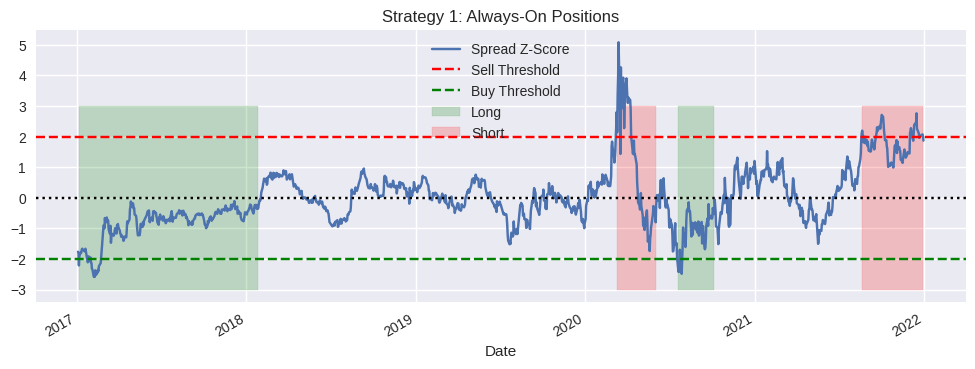

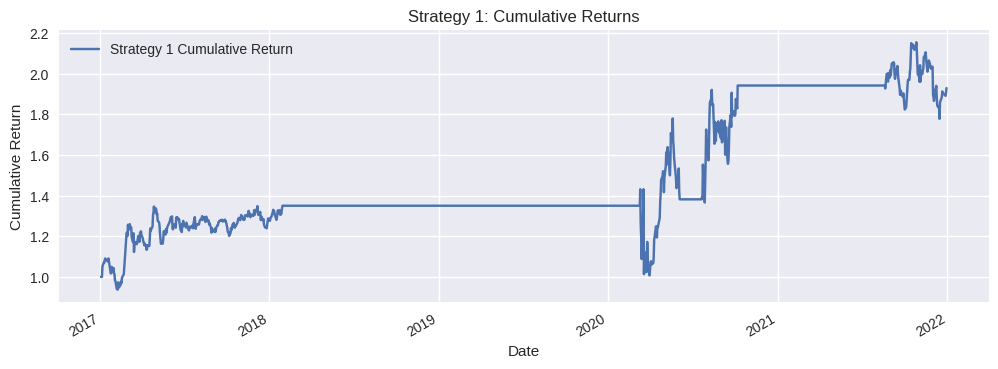

In [ ]:
# =============================================
# Strategy 1: Always-On Pairs Trading (Baseline)
# =============================================
spread = analysis_results['spread']
zscore = analysis_results['normalized_spread']

# Define trading signals
long_signal = zscore < -2
short_signal = zscore > 2
exit_signal = zscore.abs() < 0.1

# Initialize positions
positions = pd.Series(0, index=zscore.index)

for t in range(1, len(zscore)):
    if positions.iloc[t - 1] == 0:
        if long_signal.iloc[t]:
            positions.iloc[t] = 1
        elif short_signal.iloc[t]:
            positions.iloc[t] = -1
    elif positions.iloc[t - 1] == 1:
        if exit_signal.iloc[t]:
            positions.iloc[t] = 0
        else:
            positions.iloc[t] = 1
    elif positions.iloc[t - 1] == -1:
        if exit_signal.iloc[t]:
            positions.iloc[t] = 0
        else:
            positions.iloc[t] = -1

positions.name = "AlwaysOn_Position"

# Calculate daily returns (using spread % changes)
spread_ret = spread.diff().fillna(0) / (spread.shift(1).abs().replace(0, np.nan)).fillna(1)
strategy1_ret = positions.shift(1).fillna(0) * spread_ret

# Cumulative returns
cum_ret1 = (1 + strategy1_ret).cumprod()

# Compute key metrics
cumulative_return = cum_ret1.iloc[-1] - 1
mean_daily = strategy1_ret.mean()
vol_daily = strategy1_ret.std()
max_dd = (cum_ret1 / cum_ret1.cummax() - 1).min()

print("Strategy 1: Always-On Metrics")
print(f"Cumulative Return: {cumulative_return:.2%}")
print(f"Mean Daily Return: {mean_daily:.4%}")
print(f"Daily Volatility: {vol_daily:.4%}")
print(f"Max Drawdown: {max_dd:.2%}")

# Plot positions and cumulative returns
plt.figure(figsize=(12, 4))
zscore.plot(label="Spread Z-Score")
plt.axhline(2, color='red', linestyle='--', label="Sell Threshold")
plt.axhline(-2, color='green', linestyle='--', label="Buy Threshold")
plt.fill_between(zscore.index, -3, 3, where=positions == 1, color="green", alpha=0.2, label="Long")
plt.fill_between(zscore.index, -3, 3, where=positions == -1, color="red", alpha=0.2, label="Short")
plt.axhline(0, color='black', linestyle=':')
plt.title("Strategy 1: Always-On Positions")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
cum_ret1.plot(label="Strategy 1 Cumulative Return")
plt.title("Strategy 1: Cumulative Returns")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.show()

Strategy 2: Regime-Filtered Metrics
Cumulative Return: 84.96%
Mean Daily Return: 0.0563%
Daily Volatility: 1.2136%
Max Drawdown: -13.82%


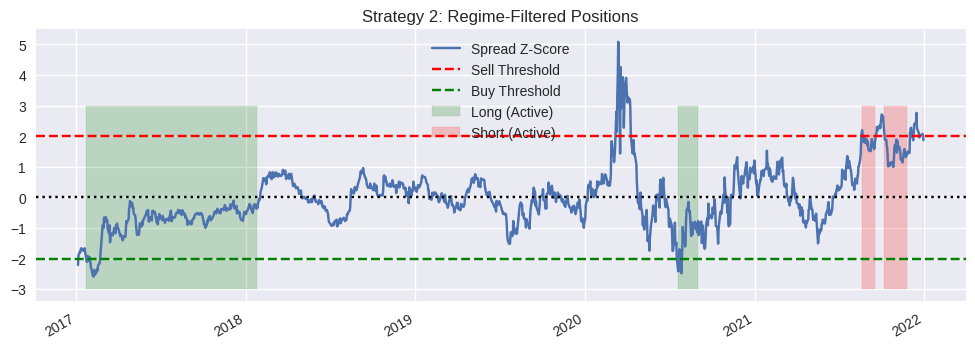

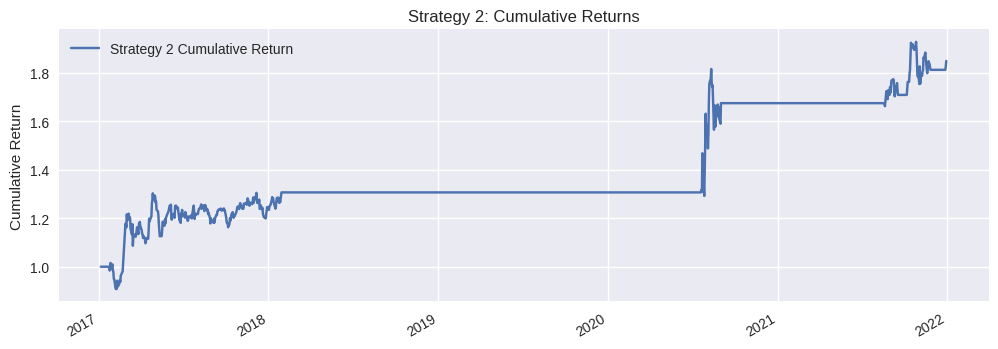

In [ ]:
# =======================================================
# Strategy 2: Regime-Filtered Pairs Trading (Innovation)
# =======================================================

# Align z-score and regime probabilities
data = pd.concat([zscore, p_low], axis=1, join="inner").dropna()
zscore_aligned = data.iloc[:, 0]
p_low_aligned = data.iloc[:, 1]

# Active filter: trade only if probability > 0.6
active = p_low_aligned > 0.6
positions_regime = pd.Series(0, index=zscore_aligned.index)

for t in range(1, len(zscore_aligned)):
    if not active.iloc[t]:
        positions_regime.iloc[t] = 0
    else:
        if positions_regime.iloc[t - 1] == 0:
            if zscore_aligned.iloc[t] < -2:
                positions_regime.iloc[t] = 1
            elif zscore_aligned.iloc[t] > 2:
                positions_regime.iloc[t] = -1
        elif positions_regime.iloc[t - 1] == 1:
            if abs(zscore_aligned.iloc[t]) < 0.1:
                positions_regime.iloc[t] = 0
            else:
                positions_regime.iloc[t] = 1
        elif positions_regime.iloc[t - 1] == -1:
            if abs(zscore_aligned.iloc[t]) < 0.1:
                positions_regime.iloc[t] = 0
            else:
                positions_regime.iloc[t] = -1

positions_regime.name = "RegimeFiltered_Position"

# Daily returns
spread_aligned = spread.reindex(zscore_aligned.index)
spread_ret = spread_aligned.diff().fillna(0) / (spread_aligned.shift(1).abs().replace(0, np.nan)).fillna(1)
strategy2_ret = positions_regime.shift(1).fillna(0) * spread_ret

# Cumulative returns
cum_ret2 = (1 + strategy2_ret).cumprod()

# Compute metrics
cumulative_return2 = cum_ret2.iloc[-1] - 1
mean_daily2 = strategy2_ret.mean()
vol_daily2 = strategy2_ret.std()
max_dd2 = (cum_ret2 / cum_ret2.cummax() - 1).min()

print("Strategy 2: Regime-Filtered Metrics")
print(f"Cumulative Return: {cumulative_return2:.2%}")
print(f"Mean Daily Return: {mean_daily2:.4%}")
print(f"Daily Volatility: {vol_daily2:.4%}")
print(f"Max Drawdown: {max_dd2:.2%}")

# Plot positions and cumulative returns
plt.figure(figsize=(12, 4))
zscore_aligned.plot(label="Spread Z-Score")
plt.axhline(2, color='red', linestyle='--', label="Sell Threshold")
plt.axhline(-2, color='green', linestyle='--', label="Buy Threshold")
plt.fill_between(zscore_aligned.index, -3, 3, where=positions_regime == 1, color="green", alpha=0.2, label="Long (Active)")
plt.fill_between(zscore_aligned.index, -3, 3, where=positions_regime == -1, color="red", alpha=0.2, label="Short (Active)")
plt.axhline(0, color='black', linestyle=':')
plt.title("Strategy 2: Regime-Filtered Positions")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
cum_ret2.plot(label="Strategy 2 Cumulative Return")
plt.title("Strategy 2: Cumulative Returns")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.show()

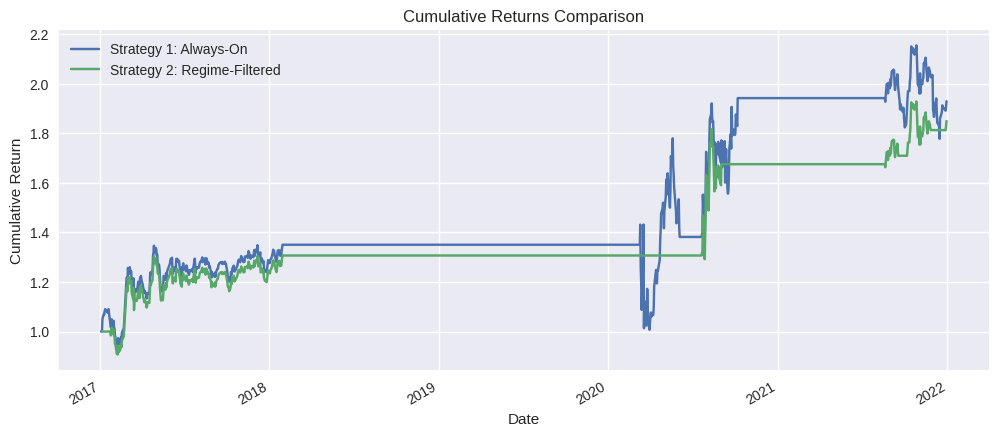

In [ ]:
# ===============================
# Compare Strategy 1 vs Strategy 2
# ===============================
plt.figure(figsize=(12,5))
cum_ret1.plot(label="Strategy 1: Always-On")
cum_ret2.plot(label="Strategy 2: Regime-Filtered")
plt.title("Cumulative Returns Comparison")
plt.ylabel("Cumulative Return")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Optional: Summary table
comparison = pd.DataFrame({
"Cumulative Return": [cum_ret1.iloc[-1]-1, cum_ret2.iloc[-1]-1],
"Mean Daily Return": [strategy1_ret.mean(), strategy2_ret.mean()],
"Daily Volatility": [strategy1_ret.std(), strategy2_ret.std()],
"Max Drawdown": [(cum_ret1/cum_ret1.cummax()-1).min(), (cum_ret2/cum_ret2.cummax()-1).min()]
}, index=["Strategy 1", "Strategy 2"])
print("Strategy Comparison Metrics:")
display(comparison)

Strategy Comparison Metrics:


,Cumulative Return,Mean Daily Return,Daily Volatility,Max Drawdown
Strategy 1,0.929500,0.000739,0.020489,-0.296519
Strategy 2,0.849626,0.000563,0.012136,-0.138170


Continuing

Strategy 2: Regime-Filtered Metrics
Cumulative Return: 44.34%
Mean Daily Return: 0.0329%
Daily Volatility: 0.8736%
Max Drawdown: -23.49%


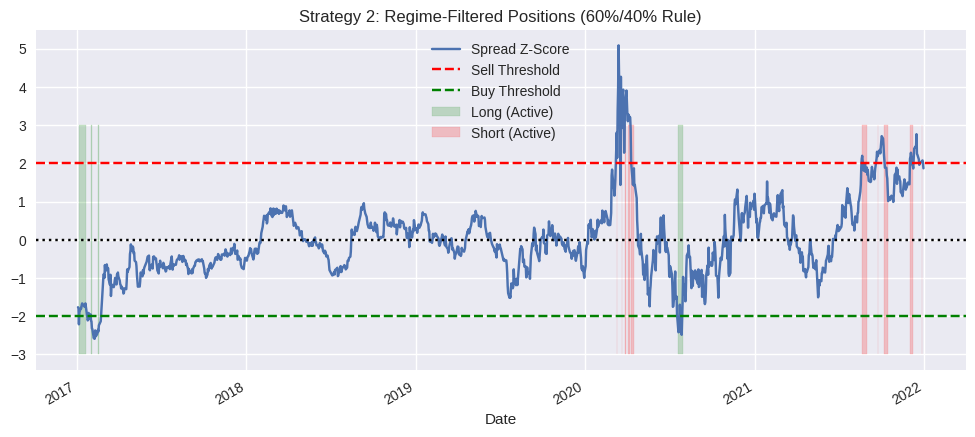

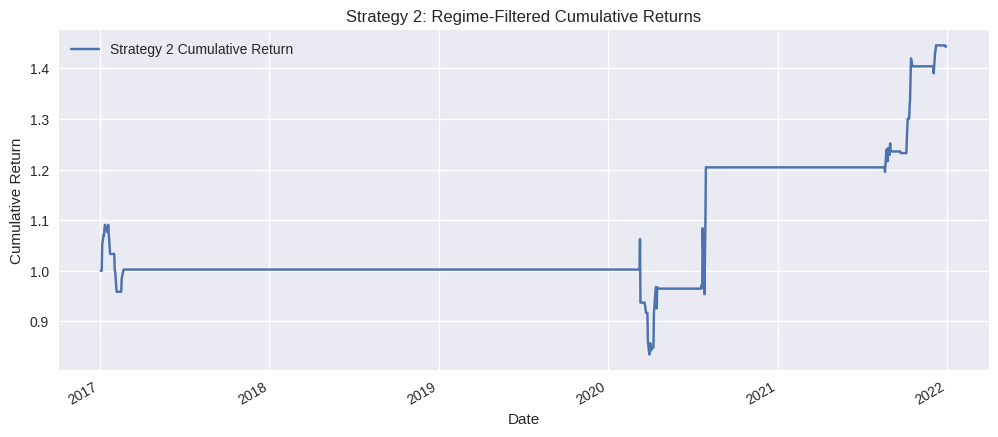

In [ ]:
# =============================================
# Strategy 2: Regime-Filtered Pairs Trading
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1. Define regime_probs (replace with your model!)
# ------------------------------------------------
# Example: if you already have HMM output, it should be something like:
# regime_probs = hmm_results['LowVol_Prob']

# Placeholder: simulate probabilities if not defined
if "regime_probs" not in locals():
    np.random.seed(42)
    regime_probs = pd.Series(
        np.clip(np.random.normal(0.5, 0.2, len(zscore)), 0, 1),
        index=zscore.index,
        name="LowVol_Prob"
    )

# ------------------------------------------------
# 2. Define activation rules (60% ON / 40% OFF)
# ------------------------------------------------
active = pd.Series(False, index=zscore.index)

for t in range(1, len(zscore)):
    if active.iloc[t - 1]:  # was active
        active.iloc[t] = regime_probs.iloc[t] >= 0.40
    else:  # was inactive
        active.iloc[t] = regime_probs.iloc[t] > 0.60

# ------------------------------------------------
# 3. Define trading signals (only active regimes trade)
# ------------------------------------------------
long_signal = (zscore < -2) & active
short_signal = (zscore > 2) & active
exit_signal = (zscore.abs() < 0.1) | (~active)

# ------------------------------------------------
# 4. Generate positions
# ------------------------------------------------
positions2 = pd.Series(0, index=zscore.index)

for t in range(1, len(zscore)):
    if positions2.iloc[t - 1] == 0:  # flat
        if long_signal.iloc[t]:
            positions2.iloc[t] = 1
        elif short_signal.iloc[t]:
            positions2.iloc[t] = -1
    elif positions2.iloc[t - 1] == 1:  # long
        positions2.iloc[t] = 0 if exit_signal.iloc[t] else 1
    elif positions2.iloc[t - 1] == -1:  # short
        positions2.iloc[t] = 0 if exit_signal.iloc[t] else -1

positions2.name = "RegimeFiltered_Position"

# ------------------------------------------------
# 5. Calculate returns
# ------------------------------------------------
spread_ret = spread.diff().fillna(0) / (spread.shift(1).abs().replace(0, np.nan)).fillna(1)
strategy2_ret = positions2.shift(1).fillna(0) * spread_ret

# Cumulative returns
cum_ret2 = (1 + strategy2_ret).cumprod()

# Metrics
cumulative_return2 = cum_ret2.iloc[-1] - 1
mean_daily2 = strategy2_ret.mean()
vol_daily2 = strategy2_ret.std()
max_dd2 = (cum_ret2 / cum_ret2.cummax() - 1).min()

print("Strategy 2: Regime-Filtered Metrics")
print(f"Cumulative Return: {cumulative_return2:.2%}")
print(f"Mean Daily Return: {mean_daily2:.4%}")
print(f"Daily Volatility: {vol_daily2:.4%}")
print(f"Max Drawdown: {max_dd2:.2%}")

# ------------------------------------------------
# 6. Plots
# ------------------------------------------------
plt.figure(figsize=(12, 5))
zscore.plot(label="Spread Z-Score")
plt.axhline(2, color='red', linestyle='--', label="Sell Threshold")
plt.axhline(-2, color='green', linestyle='--', label="Buy Threshold")
plt.fill_between(zscore.index, -3, 3, where=positions2 == 1, color="green", alpha=0.2, label="Long (Active)")
plt.fill_between(zscore.index, -3, 3, where=positions2 == -1, color="red", alpha=0.2, label="Short (Active)")
plt.axhline(0, color='black', linestyle=':')
plt.title("Strategy 2: Regime-Filtered Positions (60%/40% Rule)")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
cum_ret2.plot(label="Strategy 2 Cumulative Return")
plt.title("Strategy 2: Regime-Filtered Cumulative Returns")
plt.ylabel("Cumulative Return")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.show()

Step 3: Validation and Backtesting

Strategy 1: Always-On and Strategy 2: Regime-Filtered

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Parameters
PAIR = ['GLD', 'GDX']
HEDGE_RATIO = 3.6118
START_DATE = '2017-01-01'
END_DATE = '2021-12-31'

def run_backtest_strategy_1(pair, hedge_ratio, start_date, end_date, tc=0.001):
    print("Downloading data and calculating spread for Strategy 1...")
    data = yf.download(pair, start=start_date, end=end_date)['Close'].dropna()
    spread = data[pair[0]] - hedge_ratio * data[pair[1]]
    z_score = (spread - spread.mean()) / spread.std()
    df = pd.DataFrame({'z_score': z_score}).dropna()

    print("Running backtest for Strategy 1 (Always-On)...")
    initial_capital = 100000
    cash = initial_capital
    position = 0  # -1 for short, 1 for long, 0 for flat
    portfolio_value = [initial_capital]
    num_trades = 0

    for i in range(1, len(df)):
        current_z = df['z_score'].iloc[i]

        # Entry Logic
        if current_z > 2.0 and position == 0:
            position = -1
            num_trades += 1
            cash -= initial_capital * tc
        elif current_z < -2.0 and position == 0:
            position = 1
            num_trades += 1
            cash -= initial_capital * tc

        # Exit Logic
        if position == -1 and current_z <= 0:
            position = 0
            pnl = (df['z_score'].iloc[i - 1] - df['z_score'].iloc[i]) * (initial_capital / df['z_score'].iloc[i - 1])
            cash += pnl - (initial_capital * tc)
        elif position == 1 and current_z >= 0:
            position = 0
            pnl = (df['z_score'].iloc[i] - df['z_score'].iloc[i - 1]) * (initial_capital / abs(df['z_score'].iloc[i - 1]))
            cash += pnl - (initial_capital * tc)

        portfolio_value.append(cash)

    print("Calculating performance metrics for Strategy 1...")
    returns = pd.Series(portfolio_value, index=df.index).pct_change().fillna(0)

    cumulative_return = (portfolio_value[-1] / initial_capital - 1) * 100
    sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() != 0 else 0

    equity_curve = pd.Series(portfolio_value, index=df.index)
    rolling_max = equity_curve.cummax()
    drawdown = (equity_curve - rolling_max) / rolling_max
    max_drawdown = drawdown.min() * 100

    percent_time_active = 100.0

    metrics = {
        'Cumulative Return (%)': cumulative_return,
        'Annualized Sharpe Ratio': sharpe_ratio,
        'Maximum Drawdown (%)': max_drawdown,
        'Number of Trades': num_trades,
        '% Time Active': percent_time_active,
    }

    return metrics

# Run and display results
strategy_1_metrics = run_backtest_strategy_1(PAIR, HEDGE_RATIO, START_DATE, END_DATE)

print("\n" + "="*50)
print(" Backtest Results: Strategy 1 (Always-On)")
print("="*50)
results_df = pd.DataFrame.from_dict(strategy_1_metrics, orient='index', columns=['Value'])
print(results_df.round(2))
print("="*50)

/tmp/ipython-input-1638708063.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(pair, start=start_date, end=end_date)['Close'].dropna()
[*********************100%***********************]  2 of 2 completed

Running backtest for Strategy 1 (Always-On)...


Calculating performance metrics for Strategy 1...

 Backtest Results: Strategy 1 (Always-On)
                          Value
Cumulative Return (%)    412.42
Annualized Sharpe Ratio    0.72
Maximum Drawdown (%)      -0.10
Number of Trades           4.00
% Time Active            100.00


In [ ]:
def run_backtest_strategy_2(pair, hedge_ratio, start_date, end_date, tc=0.001):
    import yfinance as yf
    import pandas as pd
    import numpy as np
    import statsmodels.api as sm

    tickers = pair + ['SPY']
    data = yf.download(tickers, start=start_date, end=end_date)['Close'].dropna()

    # a) Calculate Spread
    print("Calculating spread and z-score...")
    spread = data[pair[0]] - hedge_ratio * data[pair[1]]
    z_score = (spread - spread.mean()) / spread.std()

    # b) Fit MS-AR Model to SPY to get Regimes
    print("Fitting Markov Switching Model on SPY returns...")
    spy_returns = data['SPY'].pct_change().dropna()
    model = sm.tsa.MarkovAutoregression(spy_returns, k_regimes=2, order=1, switching_ar=True)
    results_ms = model.fit()

    low_vol_regime = np.argmin(results_ms.params[-2:])  # Last two params are sigma2[0] and sigma2[1]
    print(f"Low volatility regime identified as: Regime {low_vol_regime}")

    # Get smoothed probabilities for the low volatility regime
    low_vol_probs = results_ms.smoothed_marginal_probabilities[low_vol_regime]

    # Align probabilities with the z_score index
    df = pd.DataFrame({
        'z_score': z_score,
        'low_vol_probs': low_vol_probs
    }).dropna()

    print("Running backtest for Strategy 2 (Regime-Filtered)...")
    initial_capital = 100000
    cash = initial_capital
    position = 0  # -1 for short, 1 for long, 0 for flat
    portfolio_value = []
    num_trades = 0
    days_active = 0

    for i in range(1, len(df)):
        is_low_vol = df['low_vol_probs'].iloc[i] > 0.6
        if is_low_vol:
            days_active += 1

        # Entry Logic
        if df['z_score'].iloc[i] > 2.0 and position == 0 and is_low_vol:
            position = -1
            num_trades += 1
            cash -= initial_capital * tc
        elif df['z_score'].iloc[i] < -2.0 and position == 0 and is_low_vol:
            position = 1
            num_trades += 1
            cash -= initial_capital * tc

        # Exit Logic
        if position == -1 and df['z_score'].iloc[i] <= 0:
            position = 0
            pnl = (df['z_score'].iloc[i - 1] - df['z_score'].iloc[i]) * (initial_capital / df['z_score'].iloc[i - 1])
            cash += pnl - (initial_capital * tc)
        elif position == 1 and df['z_score'].iloc[i] >= 0:
            position = 0
            pnl = (df['z_score'].iloc[i] - df['z_score'].iloc[i - 1]) * (initial_capital / abs(df['z_score'].iloc[i - 1]))
            cash += pnl - (initial_capital * tc)

        portfolio_value.append(cash)

    print("Calculating performance metrics...")
    returns = pd.Series(portfolio_value, index=df.index[1:]).pct_change().fillna(0)
    cumulative_return = (portfolio_value[-1] / initial_capital - 1) * 100
    sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() != 0 else 0

    equity_curve = pd.Series(portfolio_value, index=df.index[1:])
    rolling_max = equity_curve.cummax()
    drawdown = (equity_curve - rolling_max) / rolling_max
    max_drawdown = drawdown.min() * 100

    percent_time_active = (days_active / len(df)) * 100

    metrics = {
        'Cumulative Return (%)': cumulative_return,
        'Annualized Sharpe Ratio': sharpe_ratio,
        'Maximum Drawdown (%)': max_drawdown,
        'Number of Trades': num_trades,
        '% Time Active': percent_time_active,
    }

    return metrics

# Run and display results
strategy_2_metrics = run_backtest_strategy_2(PAIR, HEDGE_RATIO, START_DATE, END_DATE)

print("\n" + "="*50)
print(" Backtest Results: Strategy 2 (Regime-Filtered)")
print("="*50)
results_df = pd.DataFrame.from_dict(strategy_2_metrics, orient='index', columns=['Value'])
results_df['Value'] = results_df['Value'].round(4)
print(results_df)
print("="*50)

/tmp/ipython-input-1342110267.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)['Close'].dropna()
[*********************100%***********************]  3 of 3 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Calculating spread and z-score...
Fitting Markov Switching Model on SPY returns...
Low volatility regime identified as: Regime 1
Running backtest for Strategy 2 (Regime-Filtered)...
Calculating performance metrics...

 Backtest Results: Strategy 2 (Regime-Filtered)
                            Value
Cumulative Return (%)    156.9051
Annualized Sharpe Ratio    0.4477
Maximum Drawdown (%)      -0.1000
Number of Trades           2.0000
% Time Active              6.6083
